# Markov Decision Process (MDP)

### Ransalu Senanayake

In [ ]:
import copy
import timeit
import numpy as np
import matplotlib.pyplot as pl
%matplotlib inline
from ipywidgets import interactive
import ipywidgets as widgets

Create the following grid world.

**States:** A 10x10 grid

**Actions:** Up, Down, Left, Right

**Tranistion probabilities:**
* 0.7 in the direction of action
* 0.1 in the three other directions
* The robot bounces back to the same state near edges

**Rewards:**
* (7,8) has a reward +10
* (2,7) has a reward +3
* (4,3) has a reward -5
* (7,3) has a reward -10
* No reward in other states

This example is based on Decision Making Under Uncertainty by M.J. Kochenderfer.

In [ ]:
#Let's define MDP paras
def createGrid10World():
    def xy2s(y, x):
        x = max(x, 0)
        y = max(y, 0)
        x = min(x, 9)
        y = min(y, 9)
        out = np.ravel_multi_index(np.array([x,y]), (10,10))
        return out

    def s2xy(s):
        x, y = np.unravel_index(s, (10,10))
        return y, x

    def gridPlot(ax, im, title='', cmap='Blues'):
        pl.imshow(im, interpolation='none', cmap=cmap, origin='lower')
        pl.colorbar()
        ax.set_xticks(np.arange(0, 10, 1));
        ax.set_yticks(np.arange(0, 10, 1));
        ax.set_xticklabels(np.arange(0, 10, 1));
        ax.set_yticklabels(np.arange(0, 10, 1));
        ax.set_xticks(np.arange(-.5, 10, 1), minor=True);
        ax.set_yticks(np.arange(-.5, 10, 1), minor=True);
        ax.grid(which='minor', color='w', linestyle='-', linewidth=1)
        pl.title(title);
        return

    A = ['left', 'right', 'up', 'down']
    S = np.arange(100)
    T = np.zeros((len(S), len(A), len(S)))
    R = np.zeros((len(S), len(A)))
    for s in S:
        x, y = s2xy(s)
        if x == 2 and y == 7:
            R[s, :] = 3
        elif x == 7 and y == 8:
            R[s, :] = 10
        else:
            if x == 7 and y == 3:
                R[s, :] = -10
            elif x == 4 and y == 3:
                R[s, :] = -5
            # elif x == 0:
            #     if y == 0 or y == 9:
            #         R[s, :] = -0.2
            #     else:
            #         R[s, :] = -0.1
            #     R[s, 0] = -0.7
            # elif x == 9:
            #     if y == 0 or y == 9:
            #         R[s, :] = -0.2
            #     else:
            #         R[s, :] = -0.1
            #     R[s, 1] = -0.7
            # elif y == 0:
            #     if x == 0 or x == 9:
            #         R[s, :] = -0.2
            #     else:
            #         R[s, :] = -0.1
            #     R[s, 3] = -0.7
            # elif y == 9:
            #     if x == 0 or x == 9:
            #         R[s, :] = -0.2
            #     else:
            #         R[s, :] = -0.1
            #     R[s, 2] = -0.7

            for a in A:
                if a == 'left':
                    T[s, 0, xy2s(x - 1, y)] += 0.7
                    T[s, 0, xy2s(x + 1, y)] += 0.1
                    T[s, 0, xy2s(x, y - 1)] += 0.1
                    T[s, 0, xy2s(x, y + 1)] += 0.1
                elif a == 'right':
                    T[s, 1, xy2s(x + 1, y)] += 0.7
                    T[s, 1, xy2s(x - 1, y)] += 0.1
                    T[s, 1, xy2s(x, y - 1)] += 0.1
                    T[s, 1, xy2s(x, y + 1)] += 0.1
                elif a == 'up':
                    T[s, 2, xy2s(x, y + 1)] += 0.7
                    T[s, 2, xy2s(x, y - 1)] += 0.1
                    T[s, 2, xy2s(x - 1, y)] += 0.1
                    T[s, 2, xy2s(x + 1, y)] += 0.1
                elif a == 'down':
                    T[s, 3, xy2s(x, y - 1)] += 0.7
                    T[s, 3, xy2s(x, y + 1)] += 0.1
                    T[s, 3, xy2s(x - 1, y)] += 0.1
                    T[s, 3, xy2s(x + 1, y)] += 0.1

    # for a, c_x, c_y in [(0,0,0), (0,0,9),(1,9,0),(1,9,9),(2,0,9),(2,9,9),(3,0,0),(3,9,0)]:
    #     R[xy2s(c_x,c_c_y),a] = -0.8

    # Normalize transitions to sum to 1
    for s in S:
        for a in range(len(A)):
            sum_T = np.sum(T[s, a, :])
            if sum_T == 0:
                T[s, a, s] = 1.0 # Stay in the same state if no transitions are defined
            else:
                T[s, a, :] /= (sum_T + 1e-9) # Add a small epsilon to avoid division by zero


    discount = 0.9

    nextStates = {}
    for si in range(len(S)):
        for ai in range(len(A)):
            nextStates[(si,ai)] = np.where((T[si, ai, :] != 0) == True)[0]

    return {'S':S, 'A':A, 'T':T, 'R':R, 'discount':discount, 'nextStates':nextStates, 'gridPlot':gridPlot, 'xy2s':xy2s, 's2xy':s2xy}

In [ ]:
class MDP():
    def __init__(self):
        pass

    def inbuilt_init(self, mdp_dict):
        self.S = mdp_dict['S']
        self.A = mdp_dict['A']
        self.T = mdp_dict['T']
        self.R = mdp_dict['R']
        self.discount = mdp_dict['discount']
        self.nextStates = mdp_dict['nextStates']
        self.gridPlot = mdp_dict['gridPlot']
        self.xy2s = mdp_dict['xy2s']
        self.s2xy = mdp_dict['s2xy']

In [ ]:
#Define the MDP
mdp = MDP()
mdp.inbuilt_init(mdp_dict=createGrid10World())

#Plot states
pl.figure(figsize=(3,3))
mdp.gridPlot(ax=pl.gca(), im=mdp.S.reshape((10,10)), title='States', cmap='Greys')

#Plot rewards
pl.figure(figsize=(15,3))
pl.suptitle('Rewards', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=mdp.R[:,a].reshape((10,10)), title='a='+mdp.A[a], cmap='jet')
pl.show()

#Plot rewards
pl.figure(figsize=(15,3))
pl.suptitle('Rewards - clipped larger +ve values for visualizing the edges', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=np.clip(mdp.R[:,a].reshape((10,10)), -1, -0.5), title='a='+mdp.A[a], cmap='jet')
pl.show()

#Plot rewards
s0_x, s0_y = 3, 5
s0 = mdp.xy2s(s0_x, s0_y)
pl.figure(figsize=(15,3))
pl.suptitle('Transition probabilities T(s1|s0=({},{}),a)'.format(s0_x, s0_y), fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=mdp.T[s0,a,:].reshape((10,10)), title='a='+mdp.A[a], cmap='Blues')
pl.show()

In [ ]:
#An interactive plot of transition probabilities
def f(s0_x, s0_y, action):
    a = mdp.A.index(action)
    s0 = mdp.xy2s(int(s0_x), int(s0_y))
    pl.figure(figsize=(6,6))
    title = 'Transition probabilities T(s1|s0=({},{}),a={})'.format(int(s0_x),int(s0_y),action)
    mdp.gridPlot(ax=pl.gca(), im=mdp.T[s0,a,:].reshape((10,10)), title=title, cmap='Blues')
    pl.show()

interactive_plot = interactive(f, s0_x='4', s0_y='5', action=widgets.ToggleButtons(options=['left', 'right', 'up', 'down']))
interactive_plot

### 1. Policy evaluation

Computing the utility, U.

$U^\pi_k(s) = R(s, \pi(s)) + \gamma \sum_{s'} T(s' \mid s, \pi(s))U^\pi_{k-1}(s')$

In [ ]:
def iterativePolicyEvaluation(mdp, policy, numIterations=10):
    U = np.zeros(len(mdp.S))
    U_old = copy.copy(U)
    for t in range(numIterations):
        U_new = np.zeros(len(mdp.S))
        for s in mdp.S:
          a = policy if isinstance(policy, int) else policy[s]
          U_new[s] = mdp.R[s, a] + mdp.discount * np.sum(mdp.T[s, a, :] * U)
        U = copy.copy(U_new)
    return U

numIterations = 5
pl.figure(figsize=(15,3))
pl.suptitle('Utilities', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    U = iterativePolicyEvaluation(mdp=mdp, policy=a, numIterations=numIterations)
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='a='+mdp.A[a], cmap='jet')
pl.show()
print(np.round(U.reshape(10,10),3))

In [ ]:

def f(action, numIter=1):
    U = iterativePolicyEvaluation(mdp, policy=mdp.A.index(action), numIterations=numIter)
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
    pl.show()

interactive_plot = interactive(f, action=widgets.ToggleButtons(options=['left', 'right', 'up', 'down']),
                               numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

In [ ]:
#Value iteration
def valueIteration(mdp, numIterations=1):
    U = np.zeros(len(mdp.S))
    U_old = copy.copy(U)
    for t in range(numIterations):
        U_new = np.zeros(len(mdp.S))
        for s in mdp.S:
          U_new[s] = max([
              mdp.R[s, a] + mdp.discount * np.sum(mdp.T[s, a, s1] * U[s1] for s1 in mdp.nextStates[(s, a)])
              for a in range(len(mdp.A))
          ])
        U = copy.copy(U_new)
    return U

def policyExtration(mdp, U):
    policy = np.zeros(len(mdp.S), dtype=int)
    for s in mdp.S:
      policy[s] = np.argmax([
          mdp.R[s, a] + mdp.discount * np.sum(mdp.T[s, a, s1] * U[s1] for s1 in mdp.nextStates[(s, a)])
          for a in range(len(mdp.A))
      ])
    return policy

U = valueIteration(mdp, numIterations=2)
policy = policyExtration(mdp, U=U)
pl.figure(figsize=(3,3))
mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
for s in range(100):
    x, y = mdp.s2xy(s)
    if policy[s] == 0:
        m='\u02C2'
    elif policy[s] == 1:
        m='\u02C3'
    elif policy[s] == 2:
        m='\u02C4'
    elif policy[s] == 3:
        m='\u02C5'
    pl.text(x-0.5,y-1,m,color='k',size=20)
pl.show()

In [ ]:
def f(numIter=1):
    start_time = timeit.default_timer()
    U = valueIteration(mdp, numIterations=numIter)
    policy = policyExtration(mdp, U=U)
    elapsed = timeit.default_timer() - start_time
    print('time=', np.round(elapsed*1000,2))
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
    for s in range(100):
        x, y = mdp.s2xy(s)
        if policy[s] == 0:
            m='\u02C2'
        elif policy[s] == 1:
            m='\u02C3'
        elif policy[s] == 2:
            m='\u02C4'
        elif policy[s] == 3:
            m='\u02C5'
        pl.text(x-0.5,y-1,m,color='k',size=20)
    pl.show()

interactive_plot = interactive(f, numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

### 2. Policy iteration

Policy evaluation can be used in policy iteration:
1. Given the current policy, compute U
2. Using U, compute a new policy

In [ ]:
def policyIteration(mdp, numIterations=1):
    U_pi_k = np.zeros(len(mdp.S)) #initial values
    pi_k = np.random.randint(low=0,high=4,size=len(mdp.S),dtype=int) #initial policy
    pi_kp1 = copy.copy(pi_k)
    for t in range(numIterations):
        #Policy evaluation: compute U_pi_k
          for _ in range(20):
            U_new = np.zeros(len(mdp.S))
            for s in mdp.S:
              a = pi_k[s]
              U_new[s] = mdp.R[s, a] + mdp.discount * np.sum(
                  mdp.T[s, a, s1] * U_pi_k[s1] for s1 in mdp.nextStates[(s, a)]
              )
            U_pi_k = U_new
        #Policy improvement
          for s in mdp.S:
            action_values = []
            for a in range(len(mdp.A)):
              q_sa = mdp.R[s, a] + mdp.discount * np.sum(
                  mdp.T[s, a, s1] * U_pi_k[s1] for s1 in mdp.nextStates[(s, a)]
              )
              action_values.append(q_sa)
            pi_k = copy.copy(pi_kp1)
    return U_pi_k, pi_kp1

U_pi_k, pi_kp1 = policyIteration(mdp, numIterations=2)

In [ ]:
def f(numIter=1):
    start_time = timeit.default_timer()
    # code you want to evaluate
    value, policy = policyIteration(mdp, numIterations=numIter)
    elapsed = timeit.default_timer() - start_time
    print('time=', np.round(elapsed*1000,2))
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=value.reshape(10,10), title='Utility', cmap='jet')
    for s in range(100):
        x, y = mdp.s2xy(s)
        if policy[s] == 0:
            m='\u02C2'
        elif policy[s] == 1:
            m='\u02C3'
        elif policy[s] == 2:
            m='\u02C4'
        elif policy[s] == 3:
            m='\u02C5'
        pl.text(x-0.5,y-1,m,color='k',size=20)
    pl.show()

interactive_plot = interactive(f, numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

**IterativePolicyEvaluation - modified code**

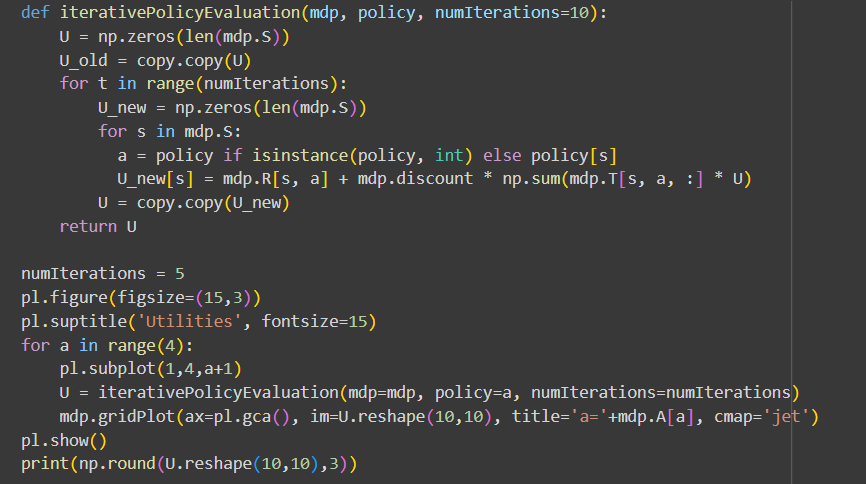

**IterativePolicyEvaluation - output**

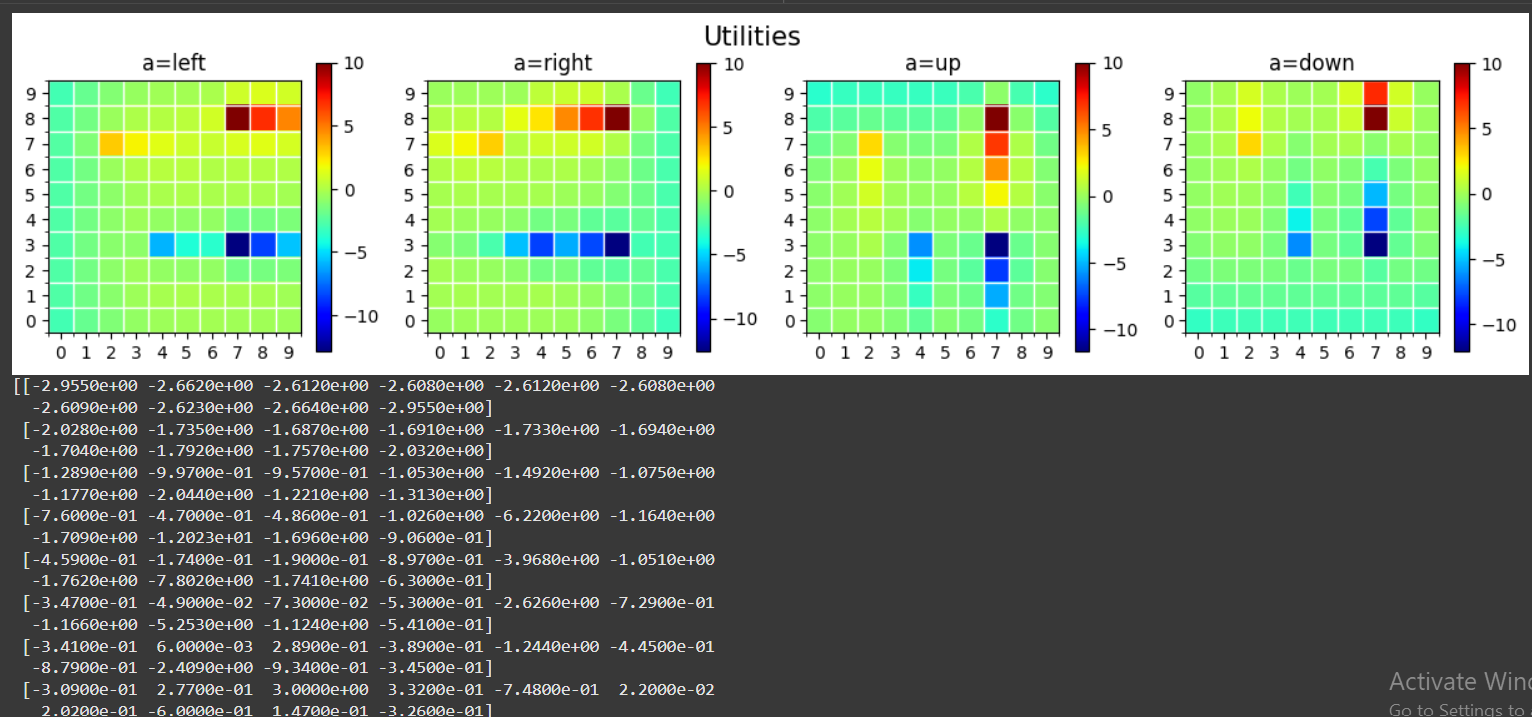

**ValueIteration and PolicyExtraction - modified code**

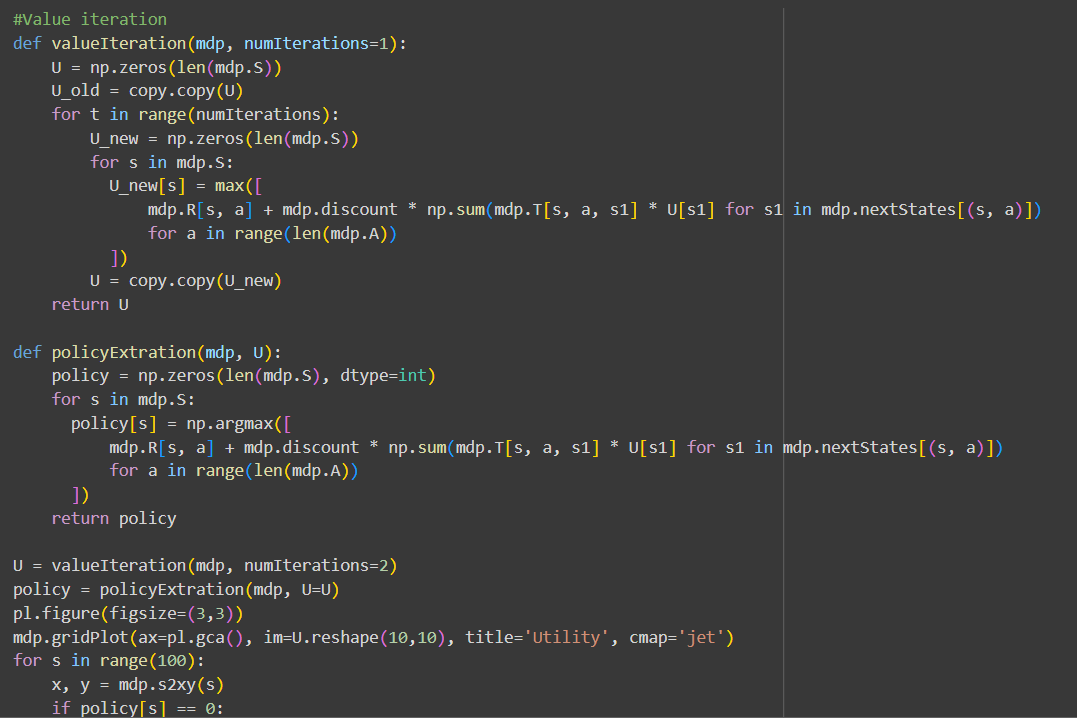

**ValueIteration and PolicyExtraction - output**

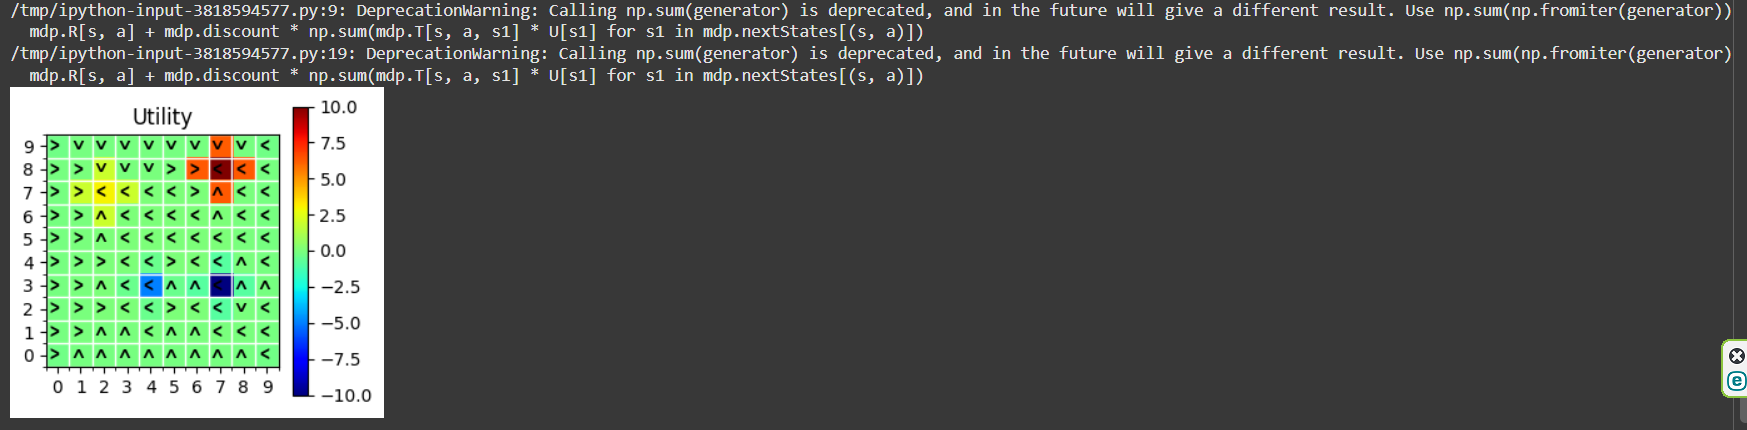

**PolicyIteration - modified code**

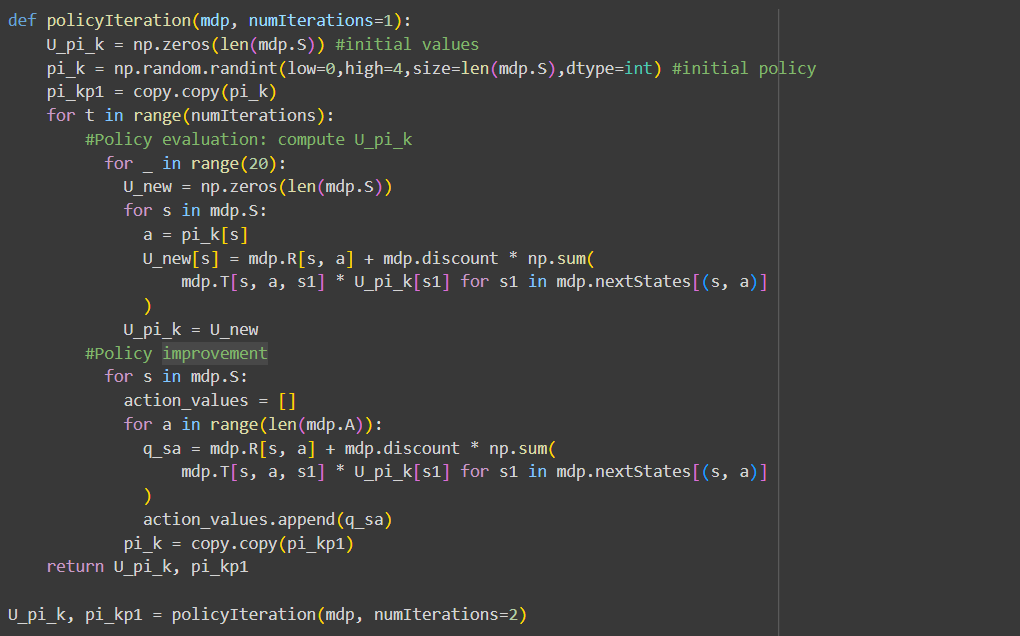

**policyIteration - ouput**

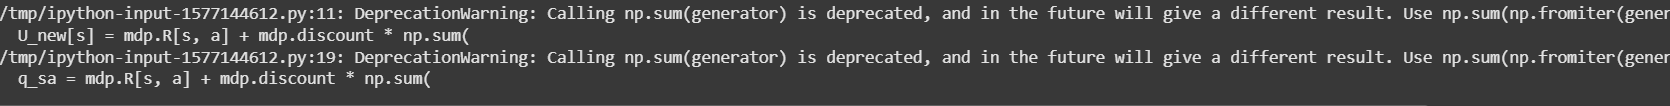

**Final- code**

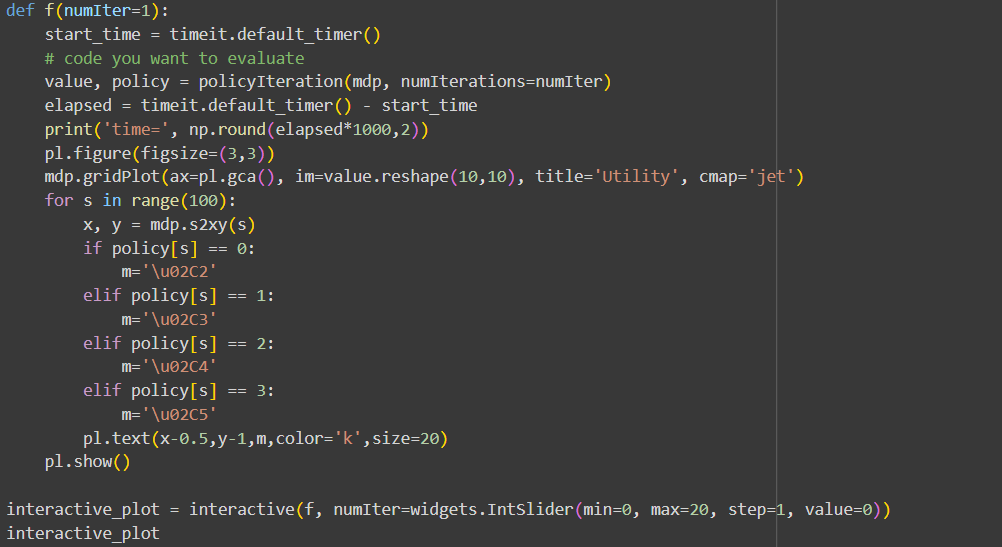

**Final - output**

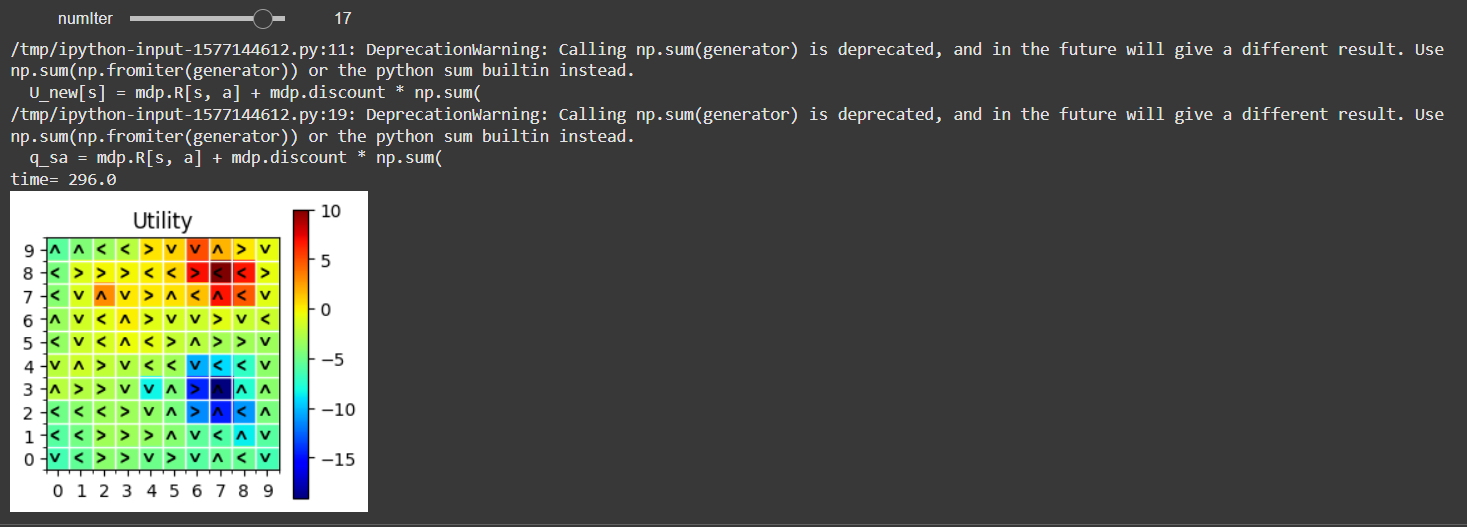

**Add Q-Learning**

In [ ]:
class QLearningAgent:
  def __init__(self, mdp, alpha=0.1, gamma=0.9, epsilon=0.05):
    self.mdp = mdp
    self.alpha = alpha
    self.gamma = gamma
    self.epsilon = epsilon
    self.q_table = dict()
    for s in mdp.S:
      self.q_table[s] = {a: 0 for a in range(len(mdp.A))}

  def choose_action(self, state):
    if np.random.rand() < self.epsilon:
      return np.random.choice(range(len(self.mdp.A)))
    else:
      q_values = self.q_table[state]
      max_q = max(q_values.values())
      best_actions = [a for a, q in q_values.items() if q == max_q]
      return np.random.choice(best_actions)

  def learn(self, state, action, reward, next_state):
    max_future_q = max(self.q_table[next_state].values())
    self.q_table[state][action] += self.alpha * (reward + self.gamma * max_future_q - self.q_table[state][action])

**Implement Q-Learning**

In [ ]:
def run_q_learning(mdp, episodes=500, max_steps=50):
  agent = QLearningAgent(mdp)
  rewards_per_episode = []

  for ep in range(episodes):
    state = np.random.choice(mdp.S)
    total_reward = 0

    for step in range(max_steps):
      action = agent.choose_action(state)
      next_state_probs = mdp.T[state, action, :]
      next_state = np.random.choice(mdp.S, p=next_state_probs)
      reward = mdp.R[state, action]

      agent.learn(state, action, reward, next_state)
      total_reward += reward
      state = next_state

    rewards_per_episode.append(total_reward)

  return rewards_per_episode, agent.q_table

**Run Model-Based Approaches**

Value Iteration



In [ ]:
def valueIteration(mdp, numIterations=50):
    U = np.zeros(len(mdp.S))
    for t in range(numIterations):
        U_new = np.zeros_like(U)
        for s in mdp.S:
            U_new[s] = max([mdp.R[s,a] + mdp.discount * sum([mdp.T[s,a,s_next]*U[s_next] for s_next in mdp.S]) for a in range(len(mdp.A))])
        U = U_new
    return U

Policy Iteration

In [ ]:
def policyIteration(mdp, numIterations=10):
    U_pi_k = np.zeros(len(mdp.S))
    pi_k = np.random.randint(0, 4, size=len(mdp.S))
    for t in range(numIterations):
        # Policy Evaluation
        for _ in range(5):  # iterative evaluation
            U_new = np.zeros_like(U_pi_k)
            for s in mdp.S:
                a = pi_k[s]
                U_new[s] = mdp.R[s,a] + mdp.discount * sum([mdp.T[s,a,s_next]*U_pi_k[s_next] for s_next in mdp.S])
            U_pi_k = U_new
        # Policy Improvement
        for s in mdp.S:
            q_values = [mdp.R[s,a] + mdp.discount * sum([mdp.T[s,a,s_next]*U_pi_k[s_next] for s_next in mdp.S]) for a in range(len(mdp.A))]
            pi_k[s] = np.argmax(q_values)
    return U_pi_k, pi_k

**Measure Execution Time & Convergence**

In [ ]:
import time
import matplotlib.pyplot as plt

# Value Iteration
start_time = time.time()
U_vi = valueIteration(mdp, numIterations=50)
vi_time = time.time() - start_time
print("Value Iteration Time: {:.4f} sec".format(vi_time))

# Policy Iteration
start_time = time.time()
U_pi, pi_policy = policyIteration(mdp, numIterations=10)
pi_time = time.time() - start_time
print("Policy Iteration Time: {:.4f} sec".format(pi_time))

# Q-Learning
start_time = time.time()
rewards_q, q_table = run_q_learning(mdp, episodes=500)
q_time = time.time() - start_time
print("Q-Learning Time: {:.4f} sec".format(q_time))

# Plot convergence comparison
plt.figure(figsize=(10,5))
plt.plot(rewards_q, label='Q-Learning cumulative reward')
plt.hlines(np.mean(U_vi), 0, len(rewards_q), colors='r', linestyles='dashed', label='Value Iteration mean utility')
plt.hlines(np.mean(U_pi), 0, len(rewards_q), colors='g', linestyles='dashed', label='Policy Iteration mean utility')
plt.xlabel('Episode / Iteration')
plt.ylabel('Reward / Utility')
plt.title('Model-Based vs Model-Free RL Convergence')
plt.legend()
plt.show()

**Difference between Model-Based and Model-Free algorithms**

**Model-Based Algorithms:**

know the environment model
use this knowledge to plan the best actions in advance.
Pros: can find optimal policies quickly if the model is accurate.
Cons: Need a complete model of the environment, which is not always available.

eg: valueIteration, policyIteration

**Model-Free Algorithms:**

do not know the environment model.
learn by trial and error, updating action values from experience.
Pros: ccan work in unknown environments, no model needed.
Cons: slower to converge, needs many interactions

eg: Q-Learning

**Result**

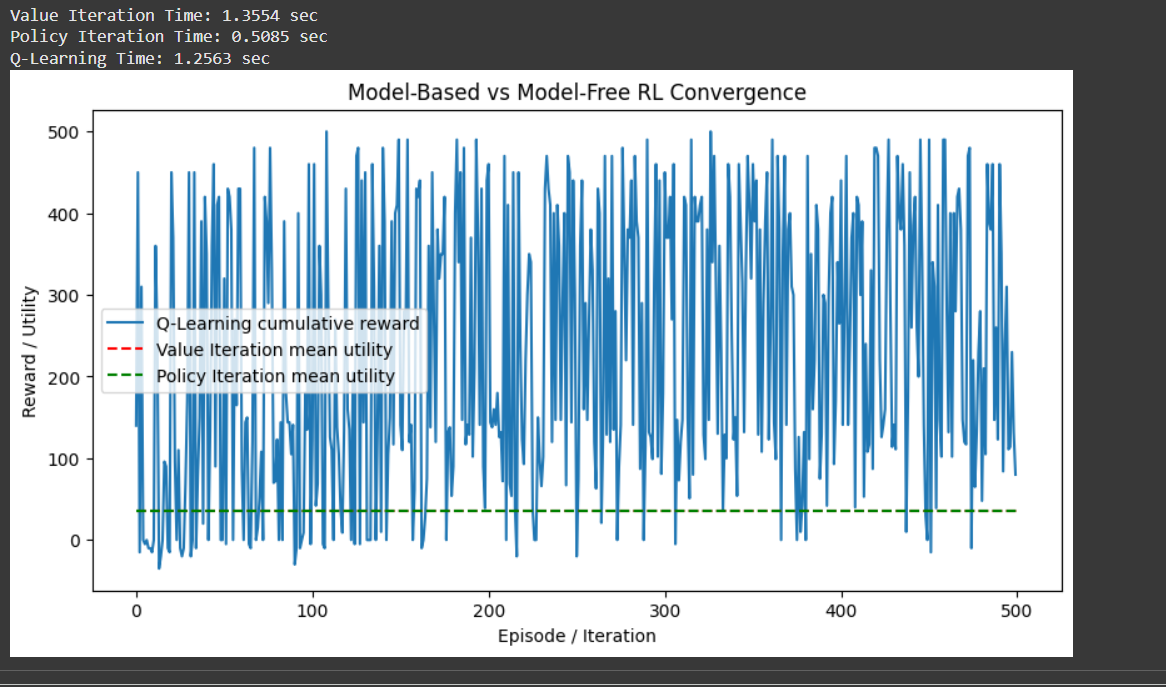

In [ ]:
from IPython.display import display
import ipywidgets as widgets

# Optional: disable widget state
for w in widgets.Widget.widgets.values():
    w.close()
